# implementasi Klasifikasi Penerima Bansos Menggunakan KNN dengan Cross-Validation

Notebook ini menggunakan KNN dengan CRISP-DM. Nilai K dipilih melalui Stratified 5-Fold Cross-Validation pada data training, lalu dievaluasi pada data testing yang terpisah.


## 1. Business Understanding (CRISP-DM)

Tujuan model adalah mengklasifikasikan status kelayakan penerima bantuan sosial (`Layak` atau `Tidak Layak`) berdasarkan jumlah tanggungan, pendapatan, pekerjaan, kondisi rumah, dan pendidikan.


In [647]:
import json
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler


In [648]:
DATASET_PATH = Path('Data_Penduduk.xlsx')
OUTPUT_DIR = Path('outputs_knn')
OUTPUT_DIR.mkdir(exist_ok=True)
TARGET_COLUMN = 'Status_Kelayakan'
TARGET_ENCODED_COLUMN = 'Status_Kelayakan_Kode'
RAW_FEATURE_COLUMNS = ['Jumlah_Tanggungan', 'Pendapatan', 'Pekerjaan', 'Kondisi_Rumah', 'Pendidikan']
FEATURE_COLUMNS = ['Jumlah_Tanggungan', 'Pendapatan', 'Pekerjaan_Kode', 'Kondisi_Rumah_Kode', 'Pendidikan_Kode']
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_SPLITS = 6
K_VALUES = [3, 5, 7, 9, 11]
print('Dataset tersedia:', DATASET_PATH.exists())


Dataset tersedia: True


## 2. Data Understanding (CRISP-DM)

Dataset dimuat tanpa mengubah data sumber, lalu diperiksa struktur, kualitas, dan distribusi kelasnya.


In [649]:
# Membaca dataset dari file Excel.
df_raw = pd.read_excel(DATASET_PATH)
print('Jumlah baris dan kolom:', df_raw.shape)
df_raw.head()


Jumlah baris dan kolom: (598, 11)


,Nomor,NIK,Nama,JK,Hub_Kel,Pendidikan,Pekerjaan,Jumlah_Tanggungan,Pendapatan,Kondisi_Rumah,Status_Kelayakan
0,1,3602191001720003,AJUM,L,Kepala Keluarga,SD,Petani/Pekebun,1,<500.000,Kurang Layak,Layak
1,2,3602192608980002,ABDUL FATAH,L,Kepala Keluarga,SLTA/Sederajat,BURUH HARIAN LEPAS,1,500.000,Kurang Layak,Layak
2,3,3602190503700004,SUGANA,L,Kepala Keluarga,SD,Petani/Pekebun,1,500.000,Sederhana,Layak
3,4,3602190103750004,SAMIN,L,Kepala Keluarga,SD,Petani/Pekebun,1,500.000-1.000.000,Kurang Layak,Layak
4,5,3602190401710001,MAMAN,L,Kepala Keluarga,SD,Wiraswasta,2,2.000.000-4.000.000,Sederhana,Tidak Layak


### Pemeriksaan Kualitas dan Karakteristik Data

Tahap ini memeriksa struktur data, tipe data, missing value, duplikat, statistik deskriptif, serta distribusi kelas target.


In [650]:
# Informasi tipe data dan jumlah data non-null.
print('Informasi dataset:')
df_raw.info()


Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Nomor              598 non-null    int64
 1   NIK                598 non-null    int64
 2   Nama               598 non-null    str  
 3   JK                 598 non-null    str  
 4   Hub_Kel            598 non-null    str  
 5   Pendidikan         598 non-null    str  
 6   Pekerjaan          598 non-null    str  
 7   Jumlah_Tanggungan  598 non-null    int64
 8   Pendapatan         598 non-null    str  
 9   Kondisi_Rumah      598 non-null    str  
 10  Status_Kelayakan   598 non-null    str  
dtypes: int64(3), str(8)
memory usage: 51.5 KB


In [651]:
# Pengecekan missing value dan duplikat pada dataset awal.
print('Jumlah missing value per kolom:')
print(df_raw.isna().sum())

print('\nJumlah data duplikat:', df_raw.duplicated().sum())


Jumlah missing value per kolom:
Nomor                0
NIK                  0
Nama                 0
JK                   0
Hub_Kel              0
Pendidikan           0
Pekerjaan            0
Jumlah_Tanggungan    0
Pendapatan           0
Kondisi_Rumah        0
Status_Kelayakan     0
dtype: int64

Jumlah data duplikat: 0


In [652]:
# Statistik deskriptif kolom numerik.
numeric_columns = df_raw.select_dtypes(include='number').columns.tolist()
print('Kolom numerik:', numeric_columns)

if numeric_columns:
    display(df_raw[numeric_columns].describe())
else:
    print('Belum ada kolom numerik pada dataset awal.')


Kolom numerik: ['Nomor', 'NIK', 'Jumlah_Tanggungan']


,Nomor,NIK,Jumlah_Tanggungan
count,598.000000,5.980000e+02,598.000000
mean,299.500000,3.602192e+15,1.831104
std,172.772008,1.611950e+09,1.151753
min,1.000000,3.602190e+15,0.000000
25%,150.250000,3.602191e+15,1.000000
50%,299.500000,3.602192e+15,2.000000
75%,448.750000,3.602192e+15,3.000000
max,598.000000,3.602197e+15,6.000000


Distribusi label awal:
Status_Kelayakan
Layak          300
Tidak Layak    298
Name: count, dtype: int64


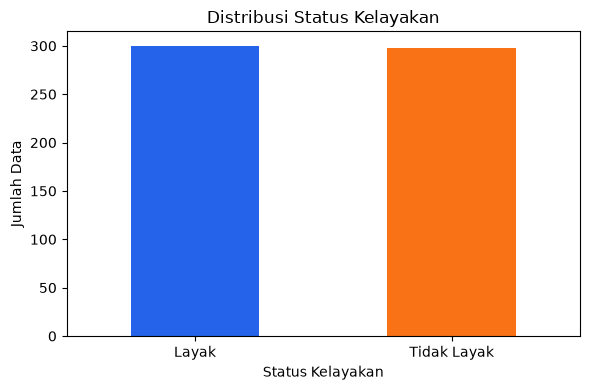

In [653]:
# Distribusi kelas target awal.
print('Distribusi label awal:')
print(df_raw[TARGET_COLUMN].value_counts(dropna=False))

label_counts = df_raw[TARGET_COLUMN].value_counts(dropna=False)
plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar', color=['#2563eb', '#f97316'])
plt.title('Distribusi Status Kelayakan')
plt.xlabel('Status Kelayakan')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 3. Data Preparation (CRISP-DM)

Tahap ini mencakup pembersihan data, standarisasi kategori, pemilihan fitur, ordinal encoding, pembagian data, dan normalisasi Min-Max di dalam pipeline cross-validation.


In [654]:
# Fungsi pembersihan dan penyeragaman data.
def clean_text(value):
    if pd.isna(value):
        return value
    return str(value).strip()


def normalize_label(value):
    value = clean_text(value)
    mapping = {
        'Tidal Layak': 'Tidak Layak',
        'tidal layak': 'Tidak Layak',
        'tidak layak': 'Tidak Layak',
        'layak': 'Layak',
    }
    return mapping.get(value, value)


def normalize_pekerjaan(value):
    value = clean_text(value)
    mapping = {
        'BURUH HARIAN LEPAS': 'Buruh Harian Lepas',
        'Buruh Harian Lepas': 'Buruh Harian Lepas',
        'Buruh Harian': 'Buruh Harian Lepas',
        'PETANI/PEKEBUN': 'Petani/Pekebun',
        'Petani': 'Petani/Pekebun',
        'Buruh Tani/Perkebunan': 'Buruh Tani',
        'GURU': 'Guru',
        'Guru Honorer': 'Karyawan Honorer',
        'Ibu Rumah Tangga': 'Mengurus Rumah Tangga',
        'Belum/Tidak Bekerja': 'Tidak Bekerja',
        'Pelajar/Mahasiswa': 'Tidak Bekerja',
        'Tentara Nasional Indonesia': 'TNI',
        'Ustadz/Mubaligh': 'Ustadz',
        'Pensiunan': 'Pensiunan',
        'Pensiunan PNS': 'Pensiunan',
        'Pegawai Negeri Sipil': 'PNS',
        'Pedagang Kecil': 'Pedagang',
        'Karyawan': 'Karyawan Swasta',
        'Ojek': 'Wiraswasta',
        'Penjahit': 'Wiraswasta',
        'wiraswasta': 'Wiraswasta',
    }
    return mapping.get(value, value)


def normalize_pendidikan(value):
    value = clean_text(value)
    mapping = {
        'Tamat SLTP/Sederajat': 'SLTP/Sederajat',
        'Tamat SLTA/Sederajat': 'SLTA/Sederajat',
        'STRATA 1 / D IV': 'D4',
    }
    return mapping.get(value, value)


def pendapatan_to_numeric(value):
    value = clean_text(value)
    mapping = {
        '<500.000': 400000,
        '500.000': 500000,
        '500.000-1.000.000': 750000,
        '1.000.000-2.000.000': 1500000,
        '2.000.000-4.000.000': 3000000,
        '>4.000.000': 4500000,
    }
    if value in mapping:
        return mapping[value]

    cleaned = value.replace('Rp', '').replace(' ', '').replace('.', '').replace(',', '.')
    try:
        return float(cleaned)
    except ValueError as exc:
        raise ValueError(f'Format pendapatan tidak dikenal: {value}') from exc


In [655]:
# Cleaning data tanpa mengubah dataset asli.
df = df_raw.copy()
print('Jumlah data sebelum cleaning:', df.shape)

text_columns = ['Pendidikan', 'Pekerjaan', 'Kondisi_Rumah', TARGET_COLUMN]
for column in text_columns:
    df[column] = df[column].apply(clean_text)

df[TARGET_COLUMN] = df[TARGET_COLUMN].apply(normalize_label)
df['Pekerjaan'] = df['Pekerjaan'].apply(normalize_pekerjaan)
df['Pendidikan'] = df['Pendidikan'].apply(normalize_pendidikan)
df['Pendapatan'] = df['Pendapatan'].apply(pendapatan_to_numeric)
df['Jumlah_Tanggungan'] = pd.to_numeric(df['Jumlah_Tanggungan'], errors='coerce')

print('Jumlah data setelah cleaning:', df.shape)
df.head()


Jumlah data sebelum cleaning: (598, 11)
Jumlah data setelah cleaning: (598, 11)


,Nomor,NIK,Nama,JK,Hub_Kel,Pendidikan,Pekerjaan,Jumlah_Tanggungan,Pendapatan,Kondisi_Rumah,Status_Kelayakan
0,1,3602191001720003,AJUM,L,Kepala Keluarga,SD,Petani/Pekebun,1,400000,Kurang Layak,Layak
1,2,3602192608980002,ABDUL FATAH,L,Kepala Keluarga,SLTA/Sederajat,Buruh Harian Lepas,1,500000,Kurang Layak,Layak
2,3,3602190503700004,SUGANA,L,Kepala Keluarga,SD,Petani/Pekebun,1,500000,Sederhana,Layak
3,4,3602190103750004,SAMIN,L,Kepala Keluarga,SD,Petani/Pekebun,1,750000,Kurang Layak,Layak
4,5,3602190401710001,MAMAN,L,Kepala Keluarga,SD,Wiraswasta,2,3000000,Sederhana,Tidak Layak


In [656]:
# Validasi missing value setelah cleaning.
missing_values = df.isna().sum()
print('Missing value setelah cleaning:')
print(missing_values)

if missing_values.sum() == 0:
    print('\nDataset tidak memiliki missing value.')
else:
    print('\nDataset masih memiliki missing value dan baris tersebut tidak digunakan pada pemodelan.')


Missing value setelah cleaning:
Nomor                0
NIK                  0
Nama                 0
JK                   0
Hub_Kel              0
Pendidikan           0
Pekerjaan            0
Jumlah_Tanggungan    0
Pendapatan           0
Kondisi_Rumah        0
Status_Kelayakan     0
dtype: int64

Dataset tidak memiliki missing value.


In [657]:
# Validasi data duplikat.
duplicates_before = df_raw.duplicated().sum()
duplicates_after = df.duplicated().sum()

print('Jumlah data duplikat sebelum cleaning:', duplicates_before)
print('Jumlah data duplikat setelah cleaning :', duplicates_after)


Jumlah data duplikat sebelum cleaning: 0
Jumlah data duplikat setelah cleaning : 0


In [658]:
# Validasi tipe data dan kategori setelah cleaning.
print('Tipe data setelah cleaning:')
print(df.dtypes)

for column in ['Pendidikan', 'Pekerjaan', 'Kondisi_Rumah', TARGET_COLUMN]:
    print(f'\nKategori {column}:')
    print(df[column].value_counts().sort_index())


Tipe data setelah cleaning:
Nomor                int64
NIK                  int64
Nama                   str
JK                     str
Hub_Kel                str
Pendidikan             str
Pekerjaan              str
Jumlah_Tanggungan    int64
Pendapatan           int64
Kondisi_Rumah          str
Status_Kelayakan       str
dtype: object

Kategori Pendidikan:
Pendidikan
D2                  3
D3                  1
D4                 17
SD                333
SLTA/Sederajat     71
SLTP/Sederajat     72
Tidak Sekolah     101
Name: count, dtype: int64

Kategori Pekerjaan:
Pekerjaan
Buruh Harian Lepas        16
Buruh Tani                 2
Guru                       7
Karyawan Honorer           2
Karyawan Swasta            8
Mengurus Rumah Tangga     53
PNS                        4
Pedagang                   2
Pensiunan                  3
Perangkat Desa             2
Perawat                    1
Perdagangan                5
Petani/Pekebun           261
TNI                        1
Tidak Beker

### Visualisasi Distribusi Fitur Utama

Visualisasi ini digunakan untuk melihat sebaran atribut utama setelah proses cleaning, sehingga karakteristik data yang digunakan dalam pemodelan dapat lebih mudah dipahami.


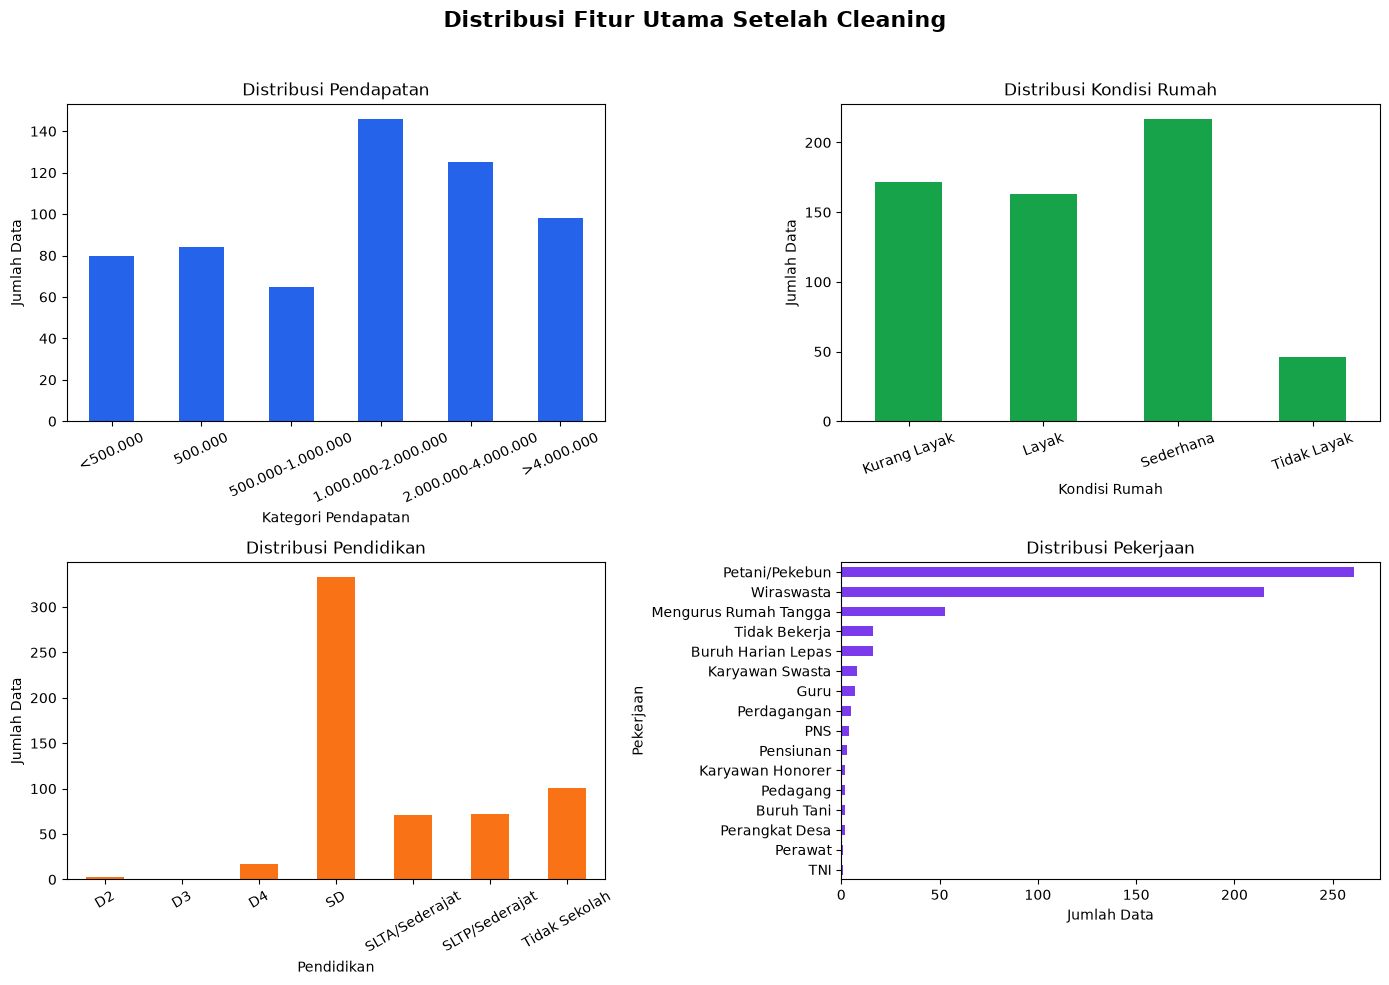

In [659]:
# Visualisasi distribusi fitur utama setelah cleaning.
def pendapatan_category_from_numeric(value):
    value = float(value)
    if value < 500000:
        return '<500.000'
    if value == 500000:
        return '500.000'
    if value <= 1000000:
        return '500.000-1.000.000'
    if value <= 2000000:
        return '1.000.000-2.000.000'
    if value <= 4000000:
        return '2.000.000-4.000.000'
    return '>4.000.000'


pendapatan_order = [
    '<500.000',
    '500.000',
    '500.000-1.000.000',
    '1.000.000-2.000.000',
    '2.000.000-4.000.000',
    '>4.000.000',
]

df_visual = df.copy()
df_visual['Pendapatan_Kategori'] = df_visual['Pendapatan'].apply(pendapatan_category_from_numeric)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribusi Fitur Utama Setelah Cleaning', fontsize=16, fontweight='bold')

df_visual['Pendapatan_Kategori'].value_counts().reindex(pendapatan_order, fill_value=0).plot(
    kind='bar', ax=axes[0, 0], color='#2563eb'
)
axes[0, 0].set_title('Distribusi Pendapatan')
axes[0, 0].set_xlabel('Kategori Pendapatan')
axes[0, 0].set_ylabel('Jumlah Data')
axes[0, 0].tick_params(axis='x', rotation=25)

df_visual['Kondisi_Rumah'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0, 1], color='#16a34a'
)
axes[0, 1].set_title('Distribusi Kondisi Rumah')
axes[0, 1].set_xlabel('Kondisi Rumah')
axes[0, 1].set_ylabel('Jumlah Data')
axes[0, 1].tick_params(axis='x', rotation=20)

df_visual['Pendidikan'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1, 0], color='#f97316'
)
axes[1, 0].set_title('Distribusi Pendidikan')
axes[1, 0].set_xlabel('Pendidikan')
axes[1, 0].set_ylabel('Jumlah Data')
axes[1, 0].tick_params(axis='x', rotation=30)

df_visual['Pekerjaan'].value_counts().sort_values().plot(
    kind='barh', ax=axes[1, 1], color='#7c3aed'
)
axes[1, 1].set_title('Distribusi Pekerjaan')
axes[1, 1].set_xlabel('Jumlah Data')
axes[1, 1].set_ylabel('Pekerjaan')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [660]:
# Feature selection sesuai variabel penelitian.
selected_columns = ['NIK', 'Nama'] + RAW_FEATURE_COLUMNS + [TARGET_COLUMN]
missing_columns = [column for column in selected_columns if column not in df.columns]

if missing_columns:
    raise KeyError(f'Kolom yang dibutuhkan belum tersedia di dataframe: {missing_columns}')

df_selected = df[selected_columns].dropna().copy()

print('Fitur yang digunakan:', RAW_FEATURE_COLUMNS)
print('Target:', TARGET_COLUMN)
print('Jumlah data setelah feature selection:', df_selected.shape)
df_selected.head()


Fitur yang digunakan: ['Jumlah_Tanggungan', 'Pendapatan', 'Pekerjaan', 'Kondisi_Rumah', 'Pendidikan']
Target: Status_Kelayakan
Jumlah data setelah feature selection: (598, 8)


,NIK,Nama,Jumlah_Tanggungan,Pendapatan,Pekerjaan,Kondisi_Rumah,Pendidikan,Status_Kelayakan
0,3602191001720003,AJUM,1,400000,Petani/Pekebun,Kurang Layak,SD,Layak
1,3602192608980002,ABDUL FATAH,1,500000,Buruh Harian Lepas,Kurang Layak,SLTA/Sederajat,Layak
2,3602190503700004,SUGANA,1,500000,Petani/Pekebun,Sederhana,SD,Layak
3,3602190103750004,SAMIN,1,750000,Petani/Pekebun,Kurang Layak,SD,Layak
4,3602190401710001,MAMAN,2,3000000,Wiraswasta,Sederhana,SD,Tidak Layak


### Data Encoding

Fitur kategorikal dan target dikonversi dengan ordinal encoding sesuai mapping yang ditetapkan. One-Hot Encoding tidak digunakan.


In [661]:
# Mapping kategori yang digunakan pada Ordinal Encoding.
PEKERJAAN_KODE_MAP = {
    'Tidak Bekerja': 1,
    'Mengurus Rumah Tangga': 1,
    'Buruh Harian Lepas': 2,
    'Buruh Tani': 2,
    'Petani/Pekebun': 3,
    'Ustadz': 3,
    'Pedagang': 3,
    'Perdagangan': 4,
    'Wiraswasta': 4,
    'Karyawan Honorer': 4,
    'Karyawan Swasta': 5,
    'Perangkat Desa': 5,
    'Perawat': 6,
    'Guru': 6,
    'Pensiunan': 6,
    'PNS': 7,
    'TNI': 7,
}

KONDISI_RUMAH_KODE_MAP = {
    'Tidak Layak': 1,
    'Kurang Layak': 2,
    'Sederhana': 3,
    'Layak': 4,
}

PENDIDIKAN_KODE_MAP = {
    'Tidak Sekolah': 1,
    'SD': 2,
    'SLTP/Sederajat': 3,
    'SLTA/Sederajat': 4,
    'D1': 5,
    'D2': 6,
    'D3': 7,
    'D4': 8,
    'S1': 9,
    'S2': 10,
    'S3': 11,
}

STATUS_KELAYAKAN_KODE_MAP = {
    'Layak': 1,
    'Tidak Layak': 0,
}

STATUS_KELAYAKAN_LABEL_MAP = {value: key for key, value in STATUS_KELAYAKAN_KODE_MAP.items()}


def encode_with_mapping(value, mapping, column_name):
    value = clean_text(value)
    if value not in mapping:
        raise ValueError(f'Kategori {column_name} tidak ditemukan pada mapping: {value}')
    return mapping[value]


In [662]:
# Proses Ordinal Encoding.
df_model = df_selected.copy()

df_model['Pekerjaan_Kode'] = df_model['Pekerjaan'].apply(
    lambda value: encode_with_mapping(value, PEKERJAAN_KODE_MAP, 'Pekerjaan')
)
df_model['Kondisi_Rumah_Kode'] = df_model['Kondisi_Rumah'].apply(
    lambda value: encode_with_mapping(value, KONDISI_RUMAH_KODE_MAP, 'Kondisi_Rumah')
)
df_model['Pendidikan_Kode'] = df_model['Pendidikan'].apply(
    lambda value: encode_with_mapping(value, PENDIDIKAN_KODE_MAP, 'Pendidikan')
)
df_model[TARGET_ENCODED_COLUMN] = df_model[TARGET_COLUMN].apply(
    lambda value: encode_with_mapping(value, STATUS_KELAYAKAN_KODE_MAP, TARGET_COLUMN)
)

df_model = df_model[FEATURE_COLUMNS + [TARGET_COLUMN, TARGET_ENCODED_COLUMN]].dropna().copy()
print('Contoh data setelah encoding:')
df_model.head(10)


Contoh data setelah encoding:


,Jumlah_Tanggungan,Pendapatan,Pekerjaan_Kode,Kondisi_Rumah_Kode,Pendidikan_Kode,Status_Kelayakan,Status_Kelayakan_Kode
0,1,400000,3,2,2,Layak,1
1,1,500000,2,2,4,Layak,1
2,1,500000,3,3,2,Layak,1
3,1,750000,3,2,2,Layak,1
4,2,3000000,4,3,2,Tidak Layak,0
5,2,500000,3,2,2,Layak,1
6,1,3000000,1,4,2,Tidak Layak,0
7,2,500000,3,2,1,Layak,1
8,4,1500000,4,2,2,Layak,1
9,2,750000,3,2,3,Layak,1


## 4. Modelling (CRISP-DM): Pembagian Data

Data dibagi secara stratified: 80% training dan 20% testing. Cross-validation hanya dilakukan pada data training agar data testing tetap objektif untuk evaluasi akhir.


In [663]:
# Memisahkan fitur dan target sebelum pembagian data.
X = df_model[FEATURE_COLUMNS].copy()
y = df_model[TARGET_ENCODED_COLUMN].copy()

print('Shape fitur:', X.shape)
print('Shape target:', y.shape)
print('\nContoh fitur sebelum normalisasi:')
X.head()


Shape fitur: (598, 5)
Shape target: (598,)

Contoh fitur sebelum normalisasi:


,Jumlah_Tanggungan,Pendapatan,Pekerjaan_Kode,Kondisi_Rumah_Kode,Pendidikan_Kode
0,1,400000,3,2,2
1,1,500000,2,2,4
2,1,500000,3,3,2
3,1,750000,3,2,2
4,2,3000000,4,3,2


In [664]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
print('Jumlah data training:', len(X_train_raw))
print('Jumlah data testing:', len(X_test_raw))
print(y_train.map(STATUS_KELAYAKAN_LABEL_MAP).value_counts())
print(y_test.map(STATUS_KELAYAKAN_LABEL_MAP).value_counts())


Jumlah data training: 478
Jumlah data testing: 120
Status_Kelayakan_Kode
Layak          240
Tidak Layak    238
Name: count, dtype: int64
Status_Kelayakan_Kode
Tidak Layak    60
Layak          60
Name: count, dtype: int64


### Visualisasi Distribusi Kelas Setelah Split


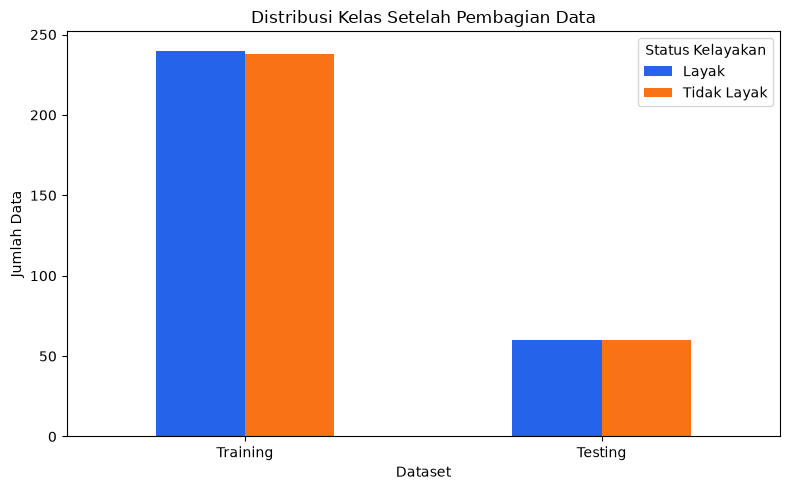

In [665]:
split_distribution = pd.DataFrame({'Training': y_train.map(STATUS_KELAYAKAN_LABEL_MAP).value_counts(), 'Testing': y_test.map(STATUS_KELAYAKAN_LABEL_MAP).value_counts()}).reindex(['Layak', 'Tidak Layak'])
ax = split_distribution.T.plot(kind='bar', figsize=(8, 5), color=['#2563eb', '#f97316'])
ax.set_title('Distribusi Kelas Setelah Pembagian Data')
ax.set_xlabel('Dataset'); ax.set_ylabel('Jumlah Data'); ax.legend(title='Status Kelayakan')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


### Normalisasi Min-Max

Dalam cross-validation, Min-Max Scaling ditempatkan di dalam pipeline sehingga scaler hanya belajar dari bagian training pada setiap fold.


In [666]:
def scale_to_dataframe(scaler, data, columns):
    return pd.DataFrame(scaler.transform(data), columns=columns, index=data.index)
evaluation_scaler = MinMaxScaler().fit(X_train_raw)
X_train = scale_to_dataframe(evaluation_scaler, X_train_raw, FEATURE_COLUMNS)
X_test = scale_to_dataframe(evaluation_scaler, X_test_raw, FEATURE_COLUMNS)
X_train.head()


,Jumlah_Tanggungan,Pendapatan,Pekerjaan_Kode,Kondisi_Rumah_Kode,Pendidikan_Kode
528,0.166667,1.000000,0.500000,1.000000,0.285714
385,0.000000,0.085366,0.333333,0.333333,0.000000
125,0.000000,0.268293,0.666667,0.666667,0.428571
366,0.000000,0.024390,0.333333,0.666667,0.142857
485,0.000000,0.634146,0.000000,0.666667,0.000000


In [667]:
# Validasi hasil normalisasi pada data training.
print('Statistik hasil normalisasi data training:')
display(X_train.describe().round(4))

print('Minimum fitur data training:')
print(X_train.min().round(4))

print('\nMaksimum fitur data training:')
print(X_train.max().round(4))


Statistik hasil normalisasi data training:


,Jumlah_Tanggungan,Pendapatan,Pekerjaan_Kode,Kondisi_Rumah_Kode,Pendidikan_Kode
count,478.0000,478.0000,478.0000,478.0000,478.0000
mean,0.2999,0.3697,0.3748,0.6046,0.1993
std,0.1883,0.3529,0.1830,0.3046,0.1923
min,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.1667,0.0244,0.3333,0.3333,0.1429
50%,0.3333,0.2683,0.3333,0.6667,0.1429
75%,0.5000,0.6341,0.5000,1.0000,0.2857
max,1.0000,1.0000,1.0000,1.0000,1.0000


Minimum fitur data training:
Jumlah_Tanggungan     0.0
Pendapatan            0.0
Pekerjaan_Kode        0.0
Kondisi_Rumah_Kode    0.0
Pendidikan_Kode       0.0
dtype: float64

Maksimum fitur data training:
Jumlah_Tanggungan     1.0
Pendapatan            1.0
Pekerjaan_Kode        1.0
Kondisi_Rumah_Kode    1.0
Pendidikan_Kode       1.0
dtype: float64


### Pemilihan Nilai K dengan Stratified Fold Cross-Validation

Setiap nilai K dievaluasi lima kali pada fold data training. K terbaik dipilih berdasarkan rata-rata Accuracy tertinggi, dengan F1-Score Macro sebagai pembanding jika hasilnya sama.


In [668]:
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scoring = {'accuracy': 'accuracy', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro', 'f1_macro': 'f1_macro'}
rows = []
for k in K_VALUES:
    pipeline = Pipeline([('scaler', MinMaxScaler()), ('knn', KNeighborsClassifier(n_neighbors=k, metric='euclidean'))])
    scores = cross_validate(pipeline, X_train_raw, y_train, cv=cv, scoring=scoring)
    rows.append({'K': k, 'Accuracy Mean': scores['test_accuracy'].mean(), 'Accuracy Std': scores['test_accuracy'].std(ddof=1), 'Precision Macro Mean': scores['test_precision_macro'].mean(), 'Recall Macro Mean': scores['test_recall_macro'].mean(), 'F1-Score Macro Mean': scores['test_f1_macro'].mean()})
cv_results_df = pd.DataFrame(rows).sort_values(['Accuracy Mean', 'F1-Score Macro Mean'], ascending=False).reset_index(drop=True)
cv_results_df.round(4)


,K,Accuracy Mean,Accuracy Std,Precision Macro Mean,Recall Macro Mean,F1-Score Macro Mean
0,3,0.9644,0.0231,0.9647,0.9644,0.9644
1,5,0.9330,0.0262,0.9334,0.9329,0.9330
2,7,0.9225,0.0314,0.9256,0.9225,0.9224
3,9,0.9184,0.0295,0.9221,0.9183,0.9182
4,11,0.9142,0.0171,0.9186,0.9140,0.9139


In [669]:
best_k = int(cv_results_df.loc[0, 'K'])
print('Nilai K terbaik dari Stratified 6-Fold Cross-Validation:', best_k)
print(cv_results_df.loc[0].round(4))


Nilai K terbaik dari Stratified 6-Fold Cross-Validation: 3
K                       3.0000
Accuracy Mean           0.9644
Accuracy Std            0.0231
Precision Macro Mean    0.9647
Recall Macro Mean       0.9644
F1-Score Macro Mean     0.9644
Name: 0, dtype: float64


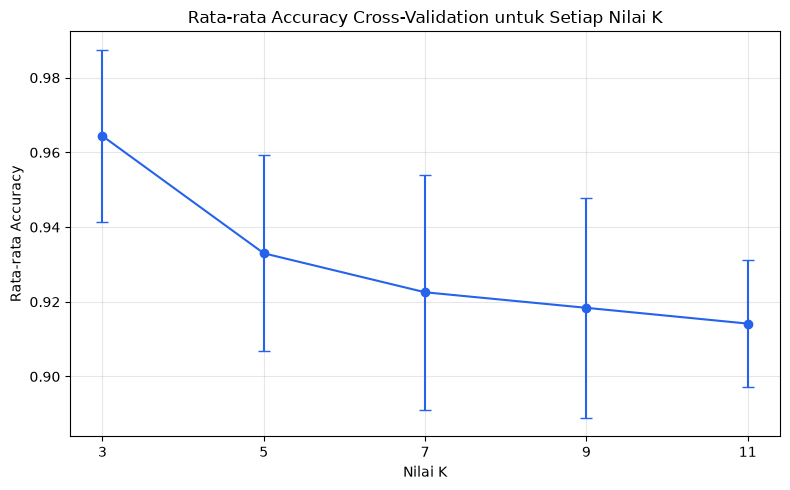

In [670]:
plt.figure(figsize=(8, 5))
plt.errorbar(cv_results_df['K'], cv_results_df['Accuracy Mean'], yerr=cv_results_df['Accuracy Std'], marker='o', capsize=4, color='#2563eb')
plt.title('Rata-rata Accuracy Cross-Validation untuk Setiap Nilai K')
plt.xlabel('Nilai K'); plt.ylabel('Rata-rata Accuracy'); plt.xticks(K_VALUES); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [671]:
best_model = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
best_model.fit(X_train, y_train)
print('Model KNN final dilatih dengan K =', best_k)


Model KNN final dilatih dengan K = 3


## 5. Evaluation (CRISP-DM): Prediksi Data Testing

Model dengan K terbaik memprediksi data testing yang tidak digunakan saat cross-validation.


In [672]:
# Prediksi data testing menggunakan model terbaik.
y_pred_best = best_model.predict(X_test)

prediction_preview = pd.DataFrame({
    'Aktual': y_test.map(STATUS_KELAYAKAN_LABEL_MAP).values,
    'Prediksi': pd.Series(y_pred_best).map(STATUS_KELAYAKAN_LABEL_MAP).values,
})

prediction_preview.head(10)


,Aktual,Prediksi
0,Tidak Layak,Tidak Layak
1,Tidak Layak,Tidak Layak
2,Layak,Layak
3,Layak,Layak
4,Layak,Layak
5,Layak,Layak
6,Tidak Layak,Tidak Layak
7,Layak,Layak
8,Layak,Layak
9,Layak,Tidak Layak


### Metrik Evaluasi dan Confusion Matrix

Metrik dihitung dari data testing yang tidak digunakan saat pemilihan nilai K maupun cross-validation.


In [673]:
# Metrik evaluasi model terbaik pada data test.
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred_best, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred_best, average='macro', zero_division=0)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1],
})
metrics_df


,Metric,Score
0,Accuracy,0.958333
1,Precision,0.958461
2,Recall,0.958333
3,F1-Score,0.958330


In [674]:
# Confusion Matrix.
cm = confusion_matrix(y_test, y_pred_best, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=['Aktual Tidak Layak', 'Aktual Layak'],
    columns=['Prediksi Tidak Layak', 'Prediksi Layak'],
)
cm_df


,Prediksi Tidak Layak,Prediksi Layak
Aktual Tidak Layak,58,2
Aktual Layak,3,57


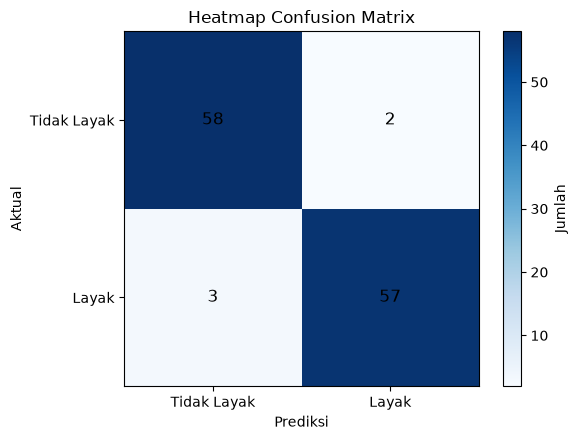

In [675]:
# Heatmap Confusion Matrix.
plt.figure(figsize=(6, 4.5))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Heatmap Confusion Matrix')
plt.colorbar(label='Jumlah')
plt.xticks([0, 1], ['Tidak Layak', 'Layak'])
plt.yticks([0, 1], ['Tidak Layak', 'Layak'])

for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        plt.text(col, row, cm[row, col], ha='center', va='center', color='black', fontsize=12)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()


In [676]:
# Classification Report dan ringkasan metrik.
print('Classification Report:')
print(classification_report(
    y_test,
    y_pred_best,
    labels=[0, 1],
    target_names=['Tidak Layak', 'Layak'],
    zero_division=0,
))

print('Accuracy :', accuracy)
print('Precision:', precision)
print('Recall   :', recall)
print('F1-Score :', f1)


Classification Report:
              precision    recall  f1-score   support

 Tidak Layak       0.95      0.97      0.96        60
       Layak       0.97      0.95      0.96        60

    accuracy                           0.96       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.96      0.96      0.96       120

Accuracy : 0.9583333333333334
Precision: 0.9584606835232008
Recall   : 0.9583333333333333
F1-Score : 0.9583304396138621


## 6. Deployment (CRISP-DM)

Setelah evaluasi, scaler dan model KNN dengan nilai K terbaik dilatih ulang pada seluruh data untuk deployment.


In [677]:
final_scaler = MinMaxScaler()
X_all_normalized = pd.DataFrame(final_scaler.fit_transform(X), columns=FEATURE_COLUMNS, index=X.index)
final_model = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean').fit(X_all_normalized, y)
model_path = OUTPUT_DIR / 'model_knn_bansos.joblib'
scaler_path = OUTPUT_DIR / 'minmax_scaler.joblib'
metadata_path = OUTPUT_DIR / 'model_metadata.json'
evaluation_path = OUTPUT_DIR / 'evaluasi_knn_test.csv'
cross_validation_path = OUTPUT_DIR / 'cross_validation_knn.csv'
joblib.dump(final_model, model_path); joblib.dump(final_scaler, scaler_path)
pd.DataFrame({'Metric': ['Accuracy', 'Precision Macro', 'Recall Macro', 'F1-Score Macro'], 'Score': [accuracy, precision, recall, f1]}).to_csv(evaluation_path, index=False)
cv_results_df.to_csv(cross_validation_path, index=False)
metadata = {'algorithm': 'KNeighborsClassifier', 'best_k': best_k, 'cross_validation': 'StratifiedKFold 5-fold pada data training', 'cv_splits': CV_SPLITS, 'test_size': TEST_SIZE, 'accuracy_test': float(accuracy), 'f1_macro_test': float(f1)}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')


239

In [678]:
# Fungsi prediksi warga baru dengan preprocessing, encoding, dan normalisasi yang sama.
def prediksi_warga_baru(pendapatan, jumlah_tanggungan, pendidikan, pekerjaan, kondisi_rumah):
    pendapatan_nilai = pendapatan_to_numeric(pendapatan) if isinstance(pendapatan, str) else pendapatan
    pekerjaan_normal = normalize_pekerjaan(pekerjaan)
    pendidikan_normal = normalize_pendidikan(pendidikan)
    kondisi_rumah_normal = clean_text(kondisi_rumah)

    input_df = pd.DataFrame([{
        'Jumlah_Tanggungan': jumlah_tanggungan,
        'Pendapatan': pendapatan_nilai,
        'Pekerjaan_Kode': encode_with_mapping(pekerjaan_normal, PEKERJAAN_KODE_MAP, 'Pekerjaan'),
        'Kondisi_Rumah_Kode': encode_with_mapping(kondisi_rumah_normal, KONDISI_RUMAH_KODE_MAP, 'Kondisi_Rumah'),
        'Pendidikan_Kode': encode_with_mapping(pendidikan_normal, PENDIDIKAN_KODE_MAP, 'Pendidikan'),
    }], columns=FEATURE_COLUMNS)

    input_normalized = pd.DataFrame(final_scaler.transform(input_df), columns=FEATURE_COLUMNS)
    prediksi_kode = int(final_model.predict(input_normalized)[0])
    prediksi_label = STATUS_KELAYAKAN_LABEL_MAP[prediksi_kode]

    probabilitas = None
    if hasattr(final_model, 'predict_proba'):
        proba = final_model.predict_proba(input_normalized)[0]
        probabilitas = {
            STATUS_KELAYAKAN_LABEL_MAP[int(kode)]: float(nilai)
            for kode, nilai in zip(final_model.classes_, proba)
        }

    return prediksi_label, probabilitas


In [679]:
# Contoh prediksi warga baru.
status, proba = prediksi_warga_baru(
    pendapatan='500.000-1.000.000',
    jumlah_tanggungan=3,
    pendidikan='SD',
    pekerjaan='Buruh Tani',
    kondisi_rumah='Kurang Layak',
)

print('Hasil prediksi:', status)
print('Probabilitas:', proba)


Hasil prediksi: Layak
Probabilitas: {'Tidak Layak': 0.0, 'Layak': 1.0}


In [680]:
df_hasil = df.copy()
df_hasil.loc[df_model.index, 'Prediksi_Kelayakan_Kode'] = final_model.predict(X_all_normalized)
df_hasil['Prediksi_Kelayakan'] = df_hasil['Prediksi_Kelayakan_Kode'].map(STATUS_KELAYAKAN_LABEL_MAP)
hasil_path = OUTPUT_DIR / 'hasil_prediksi_penduduk_knn.xlsx'
export_df = df_hasil[['NIK', 'Nama', 'Prediksi_Kelayakan']].copy()
export_df.columns = ['NIK', 'Nama', 'Status_Kelayakan']
export_df['NIK'] = export_df['NIK'].astype(str)
export_df.to_excel(hasil_path, index=False)
export_df.head()


,NIK,Nama,Status_Kelayakan
0,3602191001720003,AJUM,Layak
1,3602192608980002,ABDUL FATAH,Layak
2,3602190503700004,SUGANA,Layak
3,3602190103750004,SAMIN,Layak
4,3602190401710001,MAMAN,Tidak Layak
